# 01 · Preprocessing
**Input:** Raw MTX files from GEO accession GSE166635
**Output:** `data/processed/adata_processed.h5ad`

Covers: data loading, QC metrics, cell filtering, normalisation, log-transform,
and highly variable gene selection.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
import sys
from pathlib import Path

# ── Locate repo root and import shared paths ──────────────────────────────────
# Works regardless of where JupyterLab was launched from.
# The notebook's own __file__ is not reliable in Jupyter, so we walk upward
# from the current working directory until we find paths.py.

def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "paths.py").exists():
            return parent
    raise FileNotFoundError(
        "Could not find paths.py — make sure you cloned the full repo "
        "and ran: python scripts/data_download.py"
    )

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import (
    REPO_ROOT, RAW_DIR, PROC_DIR,
    FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR
)

print(f"Repo root  : {REPO_ROOT}")
print(f"Raw data   : {RAW_DIR}")
print(f"Processed  : {PROC_DIR}")
print(f"Figures    : {FIGURES_DIR}")


Repo root  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data   : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw
Processed  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed
Figures    : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures


## Load data

In [13]:
# Load each sample from the MTX triplet
adata1 = sc.read_10x_mtx(RAW_DIR / "HCC1", var_names="gene_symbols")
adata2 = sc.read_10x_mtx(RAW_DIR / "HCC2", var_names="gene_symbols")

adata1.obs["sample"] = "HCC1"
adata2.obs["sample"] = "HCC2"

adata1.var_names_make_unique()
adata2.var_names_make_unique()

adata = adata1.concatenate(adata2, batch_key="sample")
adata.obs["sample"] = adata.obs["sample"].map({"0": "normal (HCC1)", "1": "tumor (HCC2)"})
print(adata)
print(adata.obs["sample"].value_counts())

C:\Users\shoko\AppData\Local\Temp\ipykernel_23548\116835624.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata1.concatenate(adata2, batch_key="sample")


AnnData object with n_obs × n_vars = 25189 × 33694
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
sample
normal (HCC1)    16077
tumor (HCC2)      9112
Name: count, dtype: int64


## Quality control

In [14]:
def qc_metrics(adata):
    adata.var["mt"]   = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"]   = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt","ribo","hb"],
                                inplace=True, log1p=True)
    return adata

adata = qc_metrics(adata)

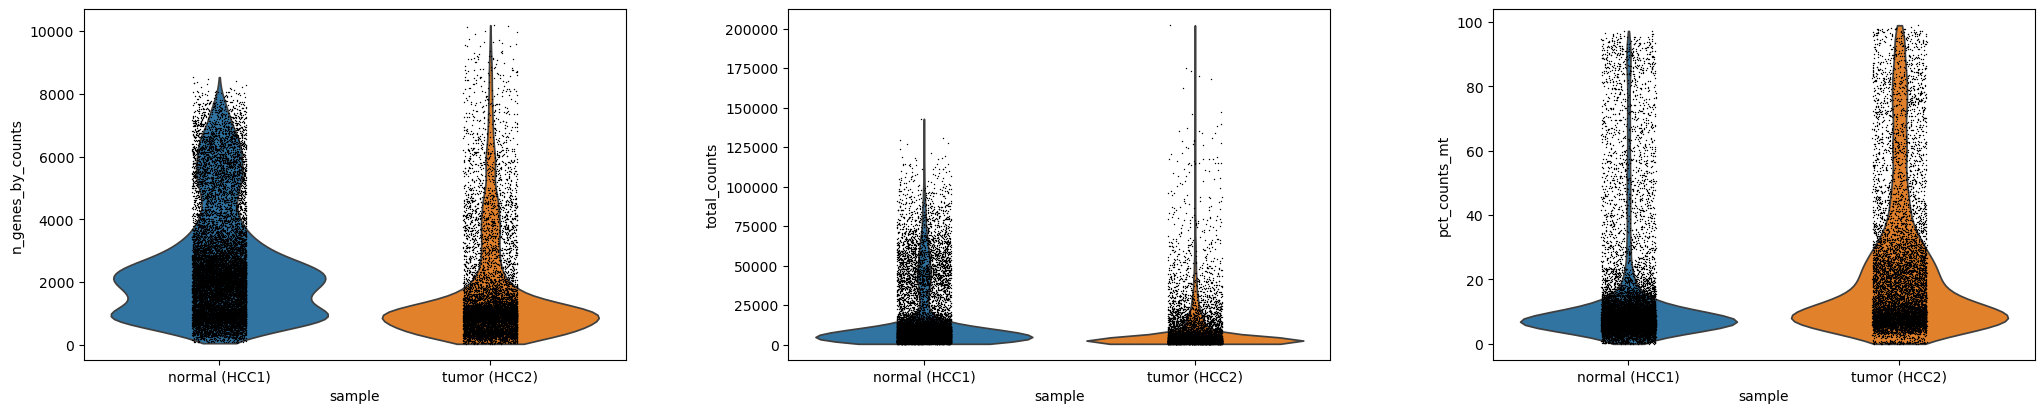

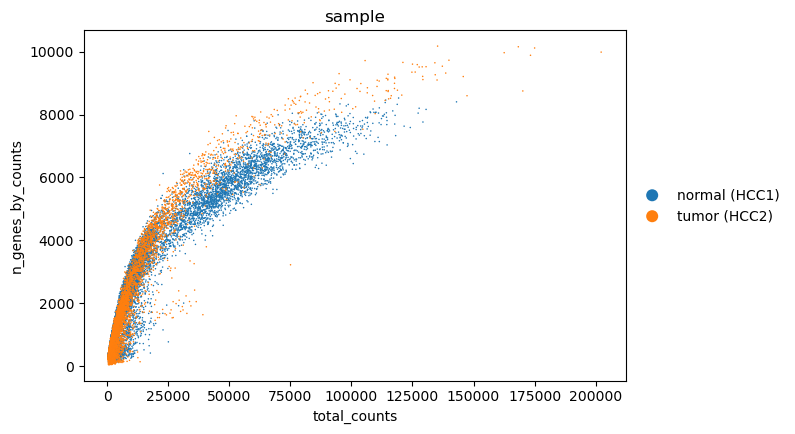

In [15]:
sc.pl.violin(adata, ["n_genes_by_counts","total_counts","pct_counts_mt"],
             groupby="sample", multi_panel=True,
             save="_qc_violin.png")
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="sample")

## Cell filtering

In [16]:
def filter_cells(adata, min_genes=200, max_genes=2500, max_mt_pct=5):
    print(f"Before filtering: {adata.n_obs} cells")
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_cells(adata, max_genes=max_genes)
    adata = adata[adata.obs["pct_counts_mt"] < max_mt_pct]
    print(f"After filtering : {adata.n_obs} cells")
    return adata

adata = filter_cells(adata)

Before filtering: 25189 cells
After filtering : 2795 cells


## Normalisation & log-transform

In [17]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()
print(f"Max expression after log1p: {adata.X.max():.2f}")

Max expression after log1p: 8.88


C:\Users\shoko\AppData\Local\Temp\ipykernel_23548\740244189.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


## Feature selection — highly variable genes

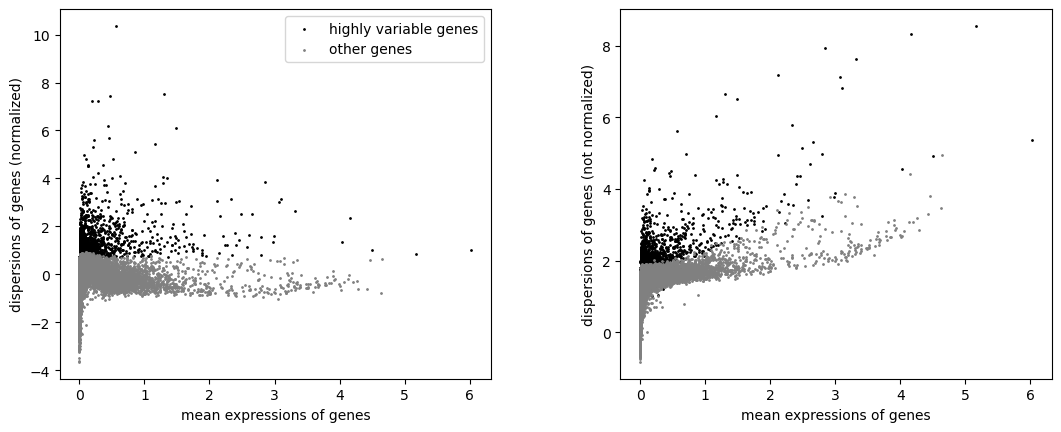

HVGs selected: 2000


In [18]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)
print(f"HVGs selected: {adata.var.highly_variable.sum()}")

## Save processed object

In [20]:
out_path = Path(str(PROC_DIR / "adata_processed.h5ad"))
out_path.parent.mkdir(parents=True, exist_ok=True)
adata.write(out_path)
print(f"Saved: {out_path}  ({adata.n_obs} cells x {adata.n_vars} genes)")

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\adata_processed.h5ad  (2795 cells x 33694 genes)
